In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
from src.datasets.multi_season_dataset import build_multi_season_dataset

raw_X_2026, raw_y_2026, final_team_states_2026 = build_multi_season_dataset(
    seasons=[2026]
)

print("raw_X_2026:", raw_X_2026.shape)
print("raw_y_2026:", raw_y_2026.shape)

Starting season 2026...
Finished season 2026: 5426 rows built, 221 skipped, 5647 raw games

All seasons complete.
Seasons processed: 1
Total rows built: 5426
Total games skipped: 221
Total raw games: 5647
All row-count checks passed.
raw_X_2026: (5426, 131)
raw_y_2026: (5426,)


In [4]:
import json

from src.preprocessing.preprocess import preprocess_X

# Preprocess 2026 without symmetrization
X_2026 = preprocess_X(
    raw_X_2026,
    prefix1="team_1_",
    prefix2="team_2_",
    diff_suffix="_diff",
    drop_base_features=True,
)

# Load the exact feature set used in the original model
with open("../../artifacts/feature_columns.json") as f:
    feature_columns = json.load(f)

# Keep only those selected features
X_2026 = X_2026[feature_columns]

y_2026 = raw_y_2026.copy()

print("X_2026:", X_2026.shape)
print("y_2026:", y_2026.shape)

--- Calculating Differentials ---
Successfully computed differentials for 62 base features:
['games_played', 'wins', 'losses', 'win_pct', 'ppg', 'papg', 'fg_pct', 'fg3_pct', 'ft_pct', 'off_rebounds_pg', 'def_rebounds_pg', 'assists_pg', 'turnovers_pg', 'steals_pg', 'blocks_pg', 'personal_fouls_pg', 'home_win_pct', 'away_win_pct', 'neutral_win_pct', 'last_5_games_played', 'last_5_win_pct', 'last_5_ppg', 'last_5_papg', 'last_5_fg_pct', 'last_5_fg3_pct', 'last_5_ft_pct', 'last_5_off_rebounds_pg', 'last_5_def_rebounds_pg', 'last_5_assists_pg', 'last_5_turnovers_pg', 'last_5_steals_pg', 'last_5_blocks_pg', 'last_5_personal_fouls_pg', 'last_5_avg_opponent_win_pct', 'last_5_avg_opponent_point_diff_pg', 'last_10_games_played', 'last_10_win_pct', 'last_10_ppg', 'last_10_papg', 'last_10_fg_pct', 'last_10_fg3_pct', 'last_10_ft_pct', 'last_10_off_rebounds_pg', 'last_10_def_rebounds_pg', 'last_10_assists_pg', 'last_10_turnovers_pg', 'last_10_steals_pg', 'last_10_blocks_pg', 'last_10_personal_fouls_p

In [5]:
old_X_test = pd.read_csv("../../data/X_test.csv")
old_y_test = pd.read_csv("../../data/y_test.csv").squeeze()

print("New non-symmetrized 2026:")
print("X:", X_2026.shape)
print("y:", y_2026.shape)

print("\nOld symmetrized test:")
print("X:", old_X_test.shape)
print("y:", old_y_test.shape)

print("\nExpected old test rows:", 2 * len(X_2026))
print("Actually doubled:", len(old_X_test) == 2 * len(X_2026))

New non-symmetrized 2026:
X: (5426, 33)
y: (5426,)

Old symmetrized test:
X: (10852, 33)
y: (10852,)

Expected old test rows: 10852
Actually doubled: True


In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

X_train = pd.read_csv("../../data/X_train.csv")
y_train = pd.read_csv("../../data/y_train.csv").squeeze()

logistic_regression = LogisticRegression(
    C=0.1,
    solver="lbfgs",
    max_iter=10000
)

logistic_regression.fit(X_train, y_train)

print("Train shape:", X_train.shape)
print("2026 shape:", X_2026.shape)
print("Columns match:", X_train.columns.equals(X_2026.columns))

Train shape: (227972, 33)
2026 shape: (5426, 33)
Columns match: True


In [24]:
y_pred = logistic_regression.predict(X_2026)
y_prob = logistic_regression.predict_proba(X_2026)

game_results = raw_X_2026[
    [
        "Season",
        "DayNum",
        "team_1_name",
        "team_2_name",
        "team_1_location",
    ]
].copy()

game_results["y_true"] = y_2026.to_numpy()
game_results["y_pred"] = y_pred
game_results["p_team_1"] = y_prob[:, 1]
game_results["p_team_2"] = y_prob[:, 0]
game_results["correct"] = game_results["y_true"] == game_results["y_pred"]

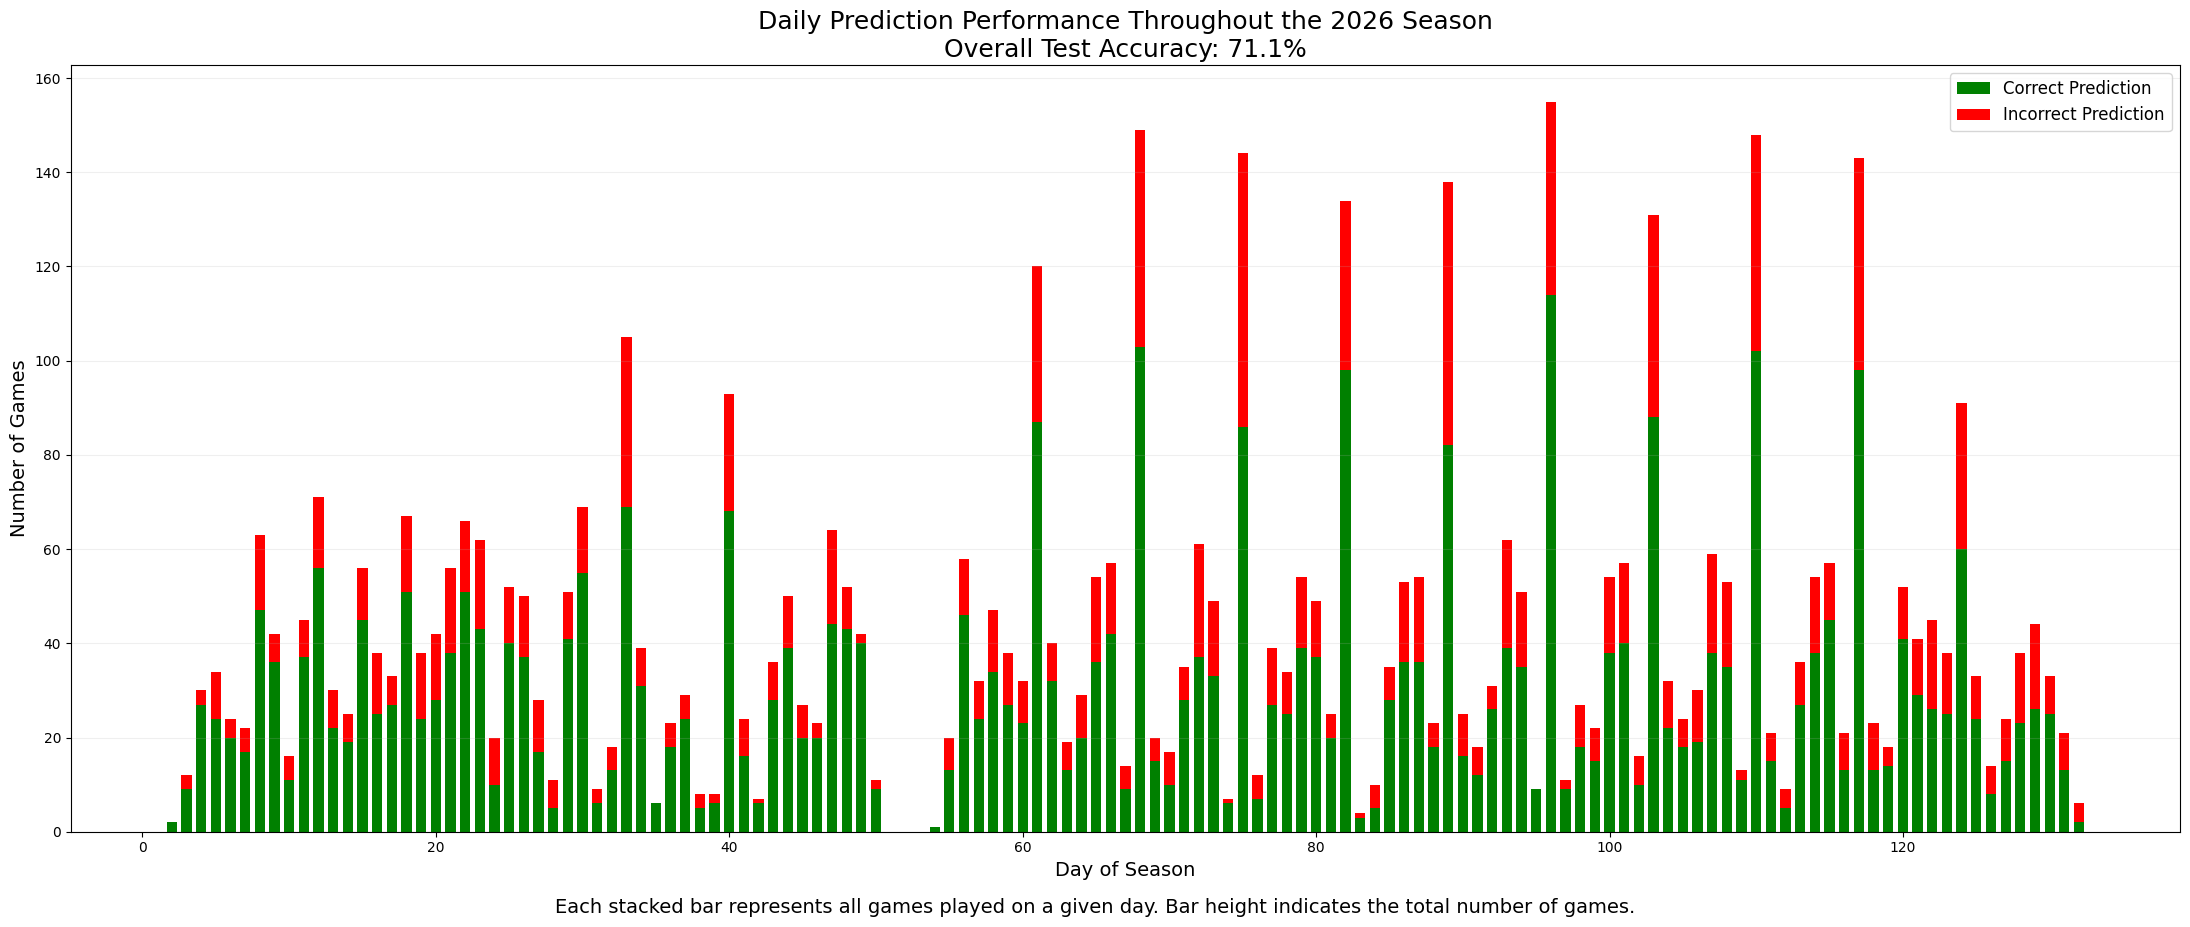

In [ ]:
import matplotlib.pyplot as plt

daily = (
    game_results
    .groupby("DayNum")["correct"]
    .agg(["sum", "count"])
    .reset_index()
)

daily["correct"] = daily["sum"]
daily["incorrect"] = daily["count"] - daily["correct"]

overall_accuracy = game_results["correct"].mean() * 100

plt.figure(figsize=(22, 9))

plt.bar(
    daily["DayNum"],
    daily["correct"],
    color="green",
    width=0.7,
    label="Correct Prediction"
)


plt.bar(
    daily["DayNum"],
    daily["incorrect"],
    bottom=daily["correct"],
    color="red",
    width=0.7,
    label="Incorrect Prediction"
)

plt.xlabel("Day of Season", fontsize=14)
plt.ylabel("Number of Games", fontsize=14)

plt.title(
    f"Daily Prediction Performance Throughout the 2026 Season\n"
    f"Overall Test Accuracy: {overall_accuracy:.1f}%",
    fontsize=18
)

plt.legend(fontsize=12)
plt.grid(axis="y", alpha=0.2)

plt.figtext(
    0.5,
    -0.02,
    "Each stacked bar represents all games played on a given day. "
    "Bar height indicates the total number of games.",
    ha="center",
    fontsize=14
)

plt.tight_layout()
plt.show()